In [4]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CI Time Series
This notebook plots the time series data for a specific procuring actor, at nodal level. The procuring actor must be chosen among the CI names and location in `CI_name_to_location`.

In particular, two plots are produced:
1) Nodal dispatch by source, including the battery usage and import from grid
2) Carbon free energy (CFE) level w/o (named `CFE score`) and w/ (named `CFE score lvl`) considering the contribution of the import from grid

In [5]:
# 0 - functions
CI_name_to_location = {
    # "Albania": "AL0 0",
    # "Austria": "AT0 0",
    # "Bosnia and Herzegovina": "BA0 0",
    # "Belgium": "BE0 0",
    # "Bulgaria": "BG0 0",
    # "Switzerland": "CH0 0",
    # "Czech Republic": "CZ0 0",
    "Germany": "DE0 0",
    # "Denmark": "DK0 0",
    # "Estonia": "EE0 0",
    # "Spain": "ES0 0",
    # "Finland": "FI1 0",
    # "France": "FR0 0",
    # "United Kingdom": "GB2 0",
    # "Greece": "GR0 0",
    # "Croatia": "HR0 0",
    # "Hungary": "HU0 0",
    # "Ireland": "IE3 0",
    # "Italy": "IT0 0",
    # "Latvia": "LT0 0",
    # "Luxembourg": "LU0 0",
    # "Lithuania": "LV0 0",
    # "Montenegro": "ME0 0",
    # "North Macedonia": "MK0 0",
    # "Netherlands": "NL0 0",
    # "Norway": "NO1 0",
    # "Poland": "PL0 0",
    # "Portugal": "PT0 0",
    # "Romania": "RO0 0",
    # "Serbia": "RS0 0",
    # "Sweden": "SE1 0",
    # "Slovenia": "SI0 0",
    # "Slovakia": "SK0 0",
    # "Kosovo": "XK0 0"
}

def align_yaxis(ax1, ax2):
    """Align zeros of the two axes, zooming them out by same ratio"""
    axes = (ax1, ax2)
    extrema = [ax.get_ylim() for ax in axes]
    tops = [extr[1] / (extr[1] - extr[0]) for extr in extrema]
    # Ensure that plots (intervals) are ordered bottom to top:
    if tops[0] > tops[1]:
        axes, extrema, tops = [list(reversed(l)) for l in (axes, extrema, tops)]

    # How much would the plot overflow if we kept current zoom levels?
    tot_span = tops[1] + 1 - tops[0]

    b_new_t = extrema[0][0] + tot_span * (extrema[0][1] - extrema[0][0])
    t_new_b = extrema[1][1] - tot_span * (extrema[1][1] - extrema[1][0])
    axes[0].set_ylim(extrema[0][0], b_new_t)
    axes[1].set_ylim(t_new_b, extrema[1][1])

def plot_ci_time_series(n, name, location, snapshot_limits, scenario_name):
    df = pd.DataFrame(index=n.snapshots)
    df[f"{name} import"] = (-n.links_t.p1[f"{name} import"])
    df[f"{name} export"] = n.links_t.p0[f"{name} export"]

    carrier_list = {f"{name} import":"import",f"{name} export":"export"}

    if "ci" in n.storage_units.columns:
        sto_i = n.storage_units[n.storage_units.ci == name].index
        df = pd.concat([df,n.storage_units_t.p[sto_i]], axis = 1)
        carrier_list.update({i: n.storage_units.loc[i, "carrier"] for i in sto_i})

    if "ci" in n.links.columns:
        link_i = n.links[n.links.ci == name].index
        df = pd.concat([df,-n.links_t.p1[link_i]], axis = 1)
        carrier_list.update({i: n.links.loc[i, "carrier"] for i in link_i})

    if "ci" in n.generators.columns:
        gen_i = n.generators[n.generators.ci == name].index
        df = pd.concat([df,n.generators_t.p[gen_i]], axis = 1)
        carrier_list.update({i: n.generators.loc[i, "carrier"] for i in gen_i})
    
    fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12,6))

    df = df.rename(columns=carrier_list)
    df = df.T.groupby(level=0).sum().T
    df = df.loc[:, df.abs().sum() >= 1]
    df *= 1e-3 # MW to GW

    colors = pd.Series(
        [n.carriers.color.get(c) or "#000000" for c in df.columns],
        index=df.columns,
        name="color"
    )

    colors["import"] = "#800080"
    colors["export"] = "#800080"

    df.clip(lower=0).plot(kind="area",stacked=True,ax=ax, color=colors, legend=False)
    df.clip(upper=0).plot(kind="area",stacked=True,ax=ax, color=colors, legend=False)

    df_load = pd.DataFrame(index=n.snapshots)
    df_load[f"{name} load"] = n.loads_t.p_set[f"{name} load"]
    df_load *= 1e-3 # MWh to TWh
    df_load.plot(ax=ax, color="black",linestyle='dashed', legend=False)
    
    cfe_line = pd.DataFrame(index=n.snapshots)
    cfe_line["CFE score"] = n.buses_t.cfe_score[location] * 100
    cfe_line.plot(ax=ax2, color="dimgrey",linestyle='dashed')

    if "cfe_lvl_score" in n.buses_t.keys():
        cfe_lvl_line = pd.DataFrame(index=n.snapshots)
        cfe_lvl_line["CFE lvl score"] = n.buses_t.cfe_lvl_score[location] * 100
        cfe_lvl_line.plot(ax=ax2, color="silver",linestyle='-.')
    
    ax.set_xlim(snapshot_limits)
    ylim = df.clip(lower=0).T.sum().max()
    ax.set_ylim([-ylim, ylim])
    ax2.set_ylim([0, 105])
    ax.set_ylabel("Dispatch (GW)")
    ax.grid(True)
    ax2.grid(True)
    
    # Crea handles e labels manualmente per la legenda #GC
    handles, labels = [], []
    for col in df.columns:
        h = plt.Rectangle((0,0),1,1, color=colors[col])
        handles.append(h)
        labels.append(col)
    # Aggiungi anche la linea di load
    handles.append(plt.Line2D([0], [0], color="black", linestyle='dashed'))
    labels.append(f"{name} load")

    ax.legend(handles, labels, bbox_to_anchor=(1, 0.5), loc='center left')
    #ax.legend(bbox_to_anchor=(1, 0.5), loc='center left')
    ax2.legend(bbox_to_anchor=(1, 0.8), loc='upper left')
    ax2.set_ylabel("CFE score [%]")

    #align_yaxis(ax, ax2)

    # --- Add Title ---
    ax.set_title(f"{scenario_name} CFE time series for {name} in 2030")

    fig.savefig(f"cfe_time_series_{scenario_name}", bbox_inches="tight")
    

--------Planning Horizon: 2025--------


INFO:pypsa.io:Imported network 247-cfe-2025-ci25-cfe100-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: 247-cfe-2025-ci25-cfe100-1H----


/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)
INFO:pypsa.io:Imported network 247-cfe-2025-ci25-cfe90-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: 247-cfe-2025-ci25-cfe90-1H----


...

INFO:pypsa.io:Imported network 247-cfe-2030-ci25-cfe100-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: 247-cfe-2030-ci25-cfe100-1H----


/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)
INFO:pypsa.io:Imported network 247-cfe-2030-ci25-cfe90-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: 247-cfe-2030-ci25-cfe90-1H----


/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)


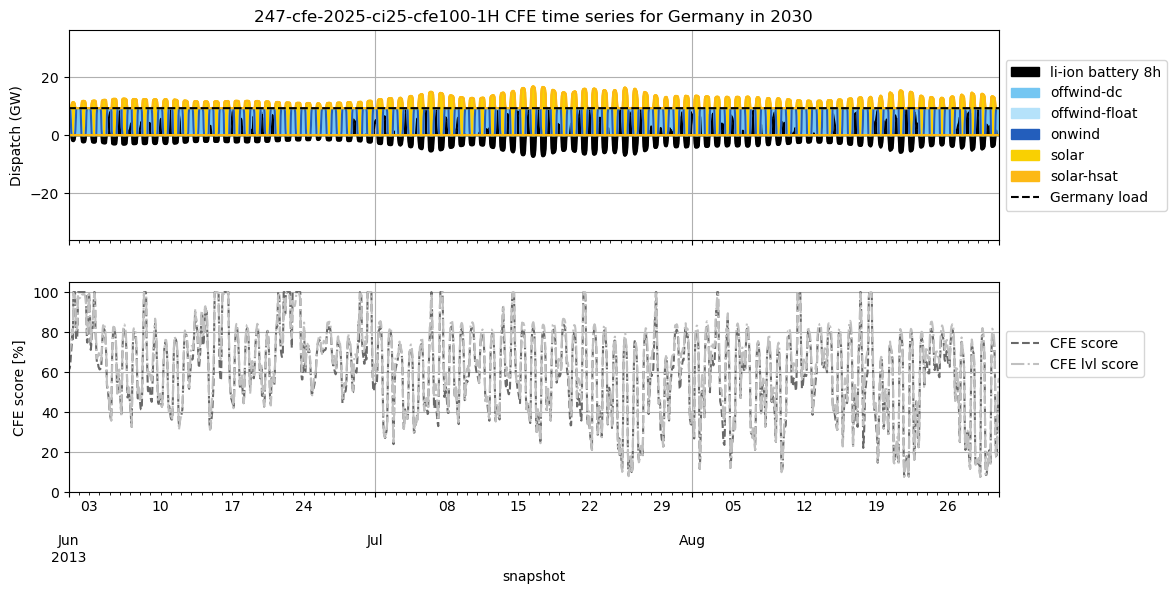

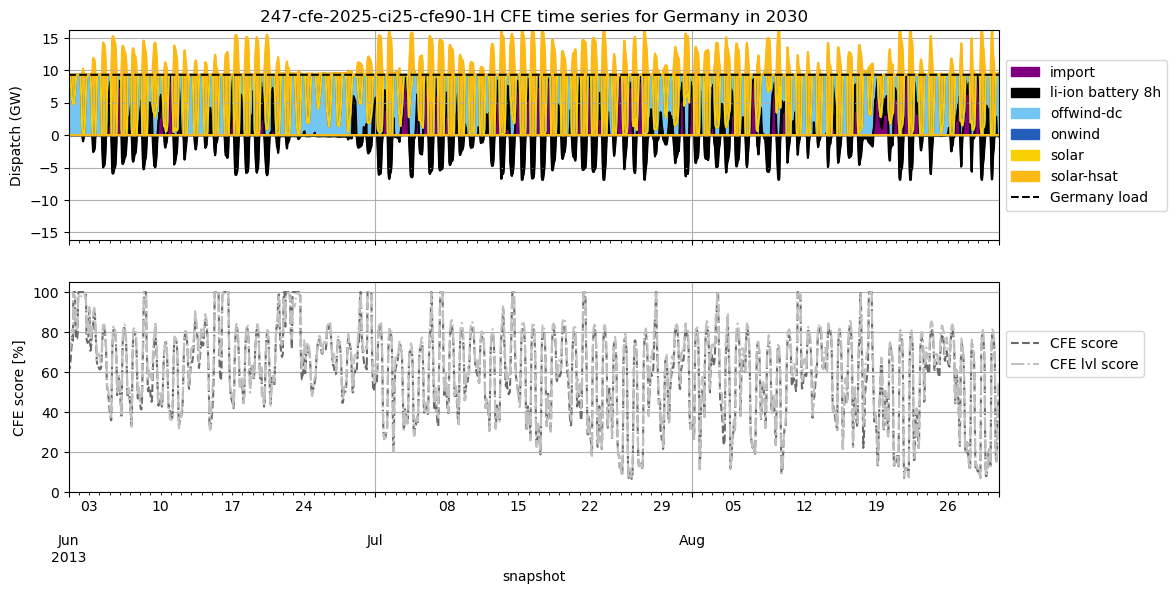

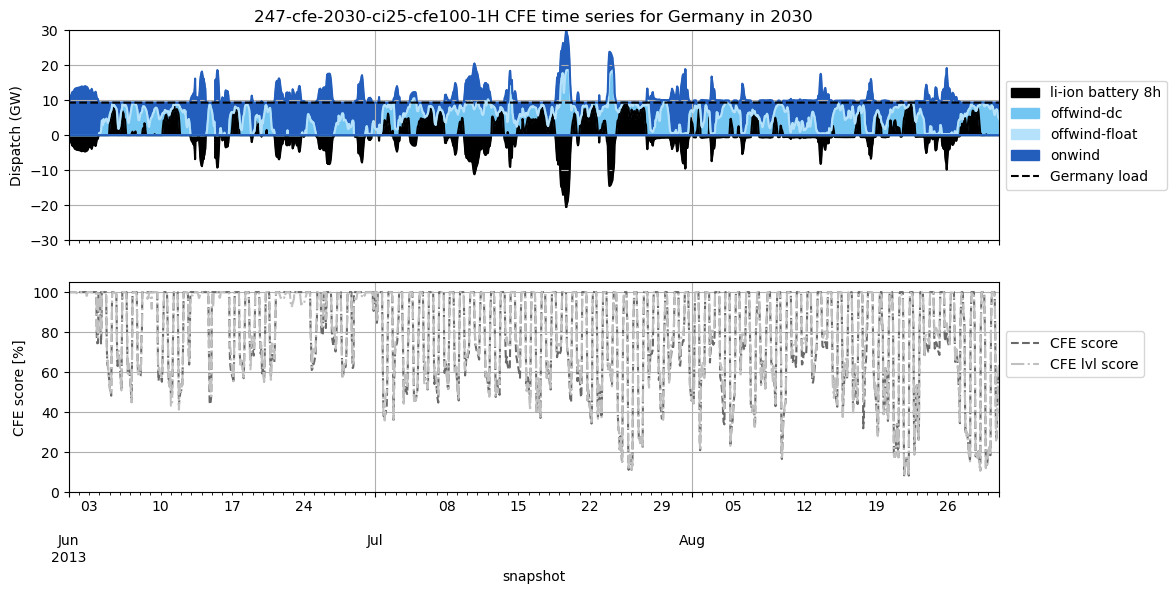

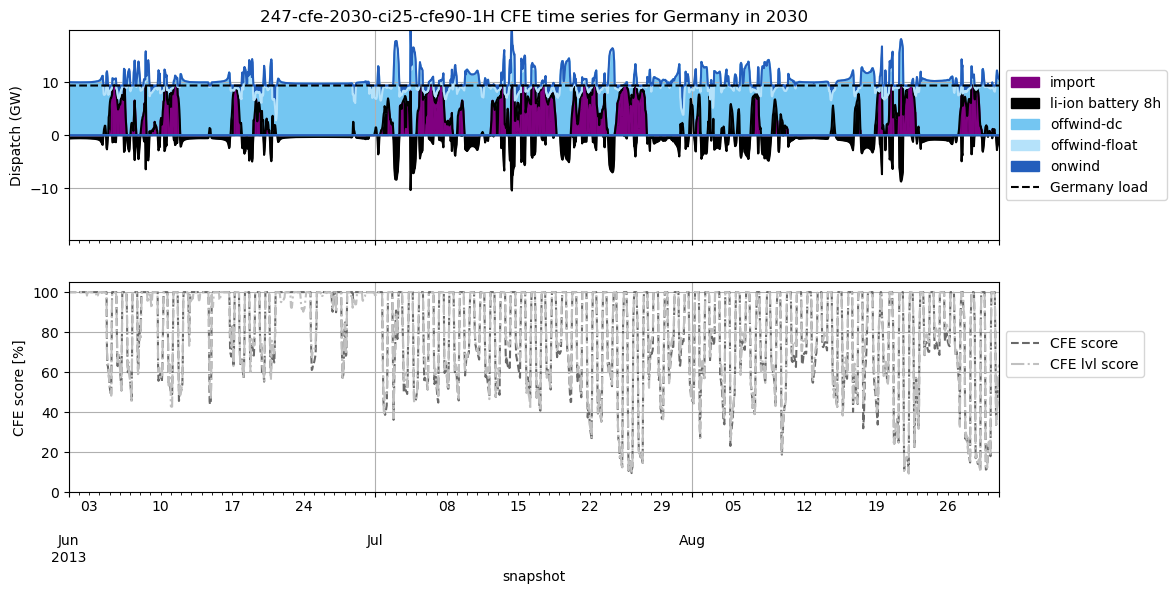

In [6]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "25"
for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")
    if planning_horizon == "2025":
        signal_source = "data"
    else:
        signal_source = "model"

    scenarios = [#f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                # f"emi-match-{planning_horizon}-ci{ci_participation}-{signal_source}-aer-{time_resolution}H",
                # f"emi-match-{planning_horizon}-ci{ci_participation}-{signal_source}-mber-{time_resolution}H",
                # #f"emi-match-{planning_horizon}-ci{ci_participation}-{signal_source}-moer-{time_resolution}H", # not working
                # f"emi-match-{planning_horizon}-ci{ci_participation}-{signal_source}-cmer-{time_resolution}H",
                ]
    
    # if planning_horizon == "2030":
        # scenarios.append(f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H")
        # scenarios.append(f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H")

    for scenario in scenarios:
        network = pypsa.Network(f"networks/{scenario}.nc")
        print(f"----Scenario: {scenario}----")
        snapshot_limits = ['2013-06-01', '2013-08-31']
        for name, location in CI_name_to_location.items():
            plot_ci_time_series(network, name, location, snapshot_limits, scenario)